In [ ]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import seaborn as sns
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

def read_yaml_file(file_path):
    import yaml
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data


In [2]:
GC_dir_path = '/Users/harryclark/Documents/data/xgboost_GC_assay/xgboost_assay_GC'
NGS_dir_path = '/Users/harryclark/Documents/data/xgboost_NGS_assay/xgboost_assay_NGS'

In [3]:
fig_path = '/Users/harryclark/Documents/figs/FIGURE2/'
# good examples include 
#mice = [25, 25, 26, 27, 29, 28]
#days = [25, 24, 18, 26, 23, 25]

In [25]:
n_neurons = np.arange(1, 500, 2)
n_neurons = np.insert(n_neurons, 0, 0) # we want the condition where no grid cells are used as a covariate history as well


In [83]:
data = pd.DataFrame()
for dir_path, trained_on in zip([GC_dir_path, NGS_dir_path], ['GC', 'NGS']):
    for file in os.listdir(dir_path):
        if file.endswith('.yaml'):
            df = pd.DataFrame()
            mouse = file.split('_')[4]
            day = file.split('_')[5].split('day')[1]
            yaml_file_path = os.path.join(dir_path, file)
            yaml_data = read_yaml_file(yaml_file_path)
            tested_on = file.split('_')[-1].split('.yaml')[0]

            if trained_on == 'NGS': # correect naming for GCs trained on NGS
                if tested_on == 'cmGC':
                    tested_on = 'GC'
                elif tested_on == 'ncmGC':
                    tested_on = 'GC'
            
            print(f'Processing mouse {mouse}, day {day}, trained on {trained_on}, tested on {tested_on}')
            for i, (key, values) in enumerate(yaml_data.items()):
                for j, val in enumerate(values):
                    df = pd.DataFrame()
                    df['mouse'] = [mouse]
                    df['day'] = [day]
                    df['trained_on'] = [trained_on]
                    df['tested_on'] = [tested_on]
                    df['n_neurons'] = [n_neurons[j]]
                    df['pR2'] = [val]
                    df['cluster_id'] = [key]
                    data = pd.concat([data, df], ignore_index=True)


Processing mouse 29, day 17, trained on GC, tested on cmGC
Processing mouse 21, day 26, trained on GC, tested on NGS
Processing mouse 21, day 18, trained on GC, tested on ncmGC
Processing mouse 29, day 19, trained on GC, tested on NGS
Processing mouse 21, day 24, trained on GC, tested on cmGC
Processing mouse 22, day 41, trained on GC, tested on NGS
Processing mouse 20, day 16, trained on GC, tested on cmGC
Processing mouse 29, day 22, trained on GC, tested on cmGC
Processing mouse 21, day 19, trained on GC, tested on NGS
Processing mouse 21, day 18, trained on GC, tested on NGS
Processing mouse 22, day 36, trained on GC, tested on NGS
Processing mouse 20, day 23, trained on GC, tested on cmGC
Processing mouse 26, day 12, trained on GC, tested on NGS
Processing mouse 22, day 34, trained on GC, tested on cmGC
Processing mouse 27, day 23, trained on GC, tested on ncmGC
Processing mouse 21, day 22, trained on GC, tested on ncmGC
Processing mouse 21, day 15, trained on GC, tested on ncmGC


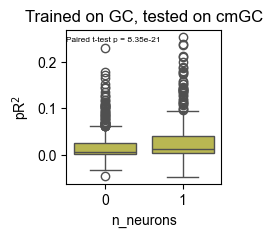

In [156]:
df_plot = data[(data['trained_on'] == 'GC') & (data['tested_on'] == 'cmGC') & (data['n_neurons'].isin([0, 1]))]
pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
pivot = pivot.dropna(subset=[0, 1])
tstat, pval = ttest_rel(pivot[0], pivot[1])

plt.figure(figsize=(2, 2))
sns.boxplot(x='n_neurons', y='pR2', data=df_plot, color='#CAC841')
plt.xlabel('n_neurons')
plt.ylabel('pR$^2$')
plt.title('Trained on GC, tested on cmGC')
plt.text(0.1, plt.ylim()[1]*0.95, f'Paired t-test p = {pval:.3g}', ha='center', va='top', fontsize=6)
plt.show()

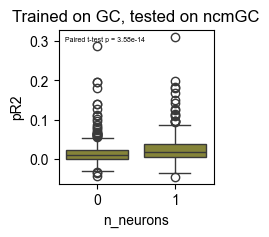

In [ ]:
df_plot = data[(data['trained_on'] == 'GC') & (data['tested_on'] == 'ncmGC') & (data['n_neurons'].isin([0, 1]))]
pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
pivot = pivot.dropna(subset=[0, 1])
tstat, pval = ttest_rel(pivot[0], pivot[1])

plt.figure(figsize=(2, 2))
sns.boxplot(x='n_neurons', y='pR2', data=df_plot, color="#92902C")
plt.xlabel('n_neurons')
plt.ylabel('pR$^2$')
plt.title('Trained on GC, tested on ncmGC')
plt.text(0.1, plt.ylim()[1]*0.95, f'Paired t-test p = {pval:.3g}', ha='center', va='top', fontsize=6)
plt.show()

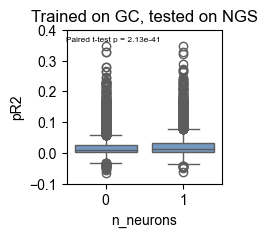

In [ ]:
df_plot = data[(data['trained_on'] == 'GC') & (data['tested_on'] == 'NGS') & (data['n_neurons'].isin([0, 1]))]
pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
pivot = pivot.dropna(subset=[0, 1])
tstat, pval = ttest_rel(pivot[0], pivot[1])

plt.figure(figsize=(2, 2))
sns.boxplot(x='n_neurons', y='pR2', data=df_plot, color='#6897CD')
plt.xlabel('n_neurons')
plt.ylabel('pR$^2$')
plt.title('Trained on GC, tested on NGS')
plt.ylim(-0.1, 0.4)
plt.text(0.1, plt.ylim()[1]*0.95, f'Paired t-test p = {pval:.3g}', ha='center', va='top', fontsize=6)
plt.show()

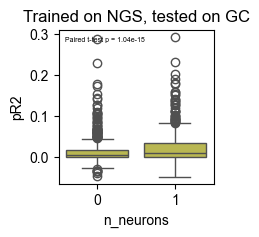

In [ ]:
df_plot = data[(data['trained_on'] == 'NGS') & (data['tested_on'] == 'GC') & (data['n_neurons'].isin([0, 1]))]
pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
pivot = pivot.dropna(subset=[0, 1])
tstat, pval = ttest_rel(pivot[0], pivot[1])

plt.figure(figsize=(2, 2))
sns.boxplot(x='n_neurons', y='pR2', data=df_plot, color='#CAC841')
plt.xlabel('n_neurons')
plt.ylabel('pR$^2$')
plt.title('Trained on NGS, tested on GC')
plt.text(0.1, plt.ylim()[1]*0.95, f'Paired t-test p = {pval:.3g}', ha='center', va='top', fontsize=5)
plt.show()

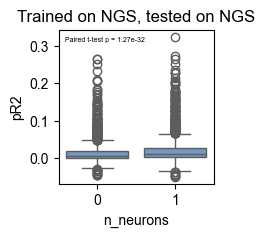

In [ ]:
df_plot = data[(data['trained_on'] == 'NGS') & (data['tested_on'] == 'NGS') & (data['n_neurons'].isin([0, 1]))]
pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
pivot = pivot.dropna(subset=[0, 1])
tstat, pval = ttest_rel(pivot[0], pivot[1])

plt.figure(figsize=(2, 2))
sns.boxplot(x='n_neurons', y='pR2', data=df_plot, color='#6897CD')
plt.xlabel('n_neurons')
plt.ylabel('pR$^2$')
plt.title('Trained on NGS, tested on NGS')
plt.text(0.1, plt.ylim()[1]*0.95, f'Paired t-test p = {pval:.3g}', ha='center', va='top', fontsize=5)
plt.show()

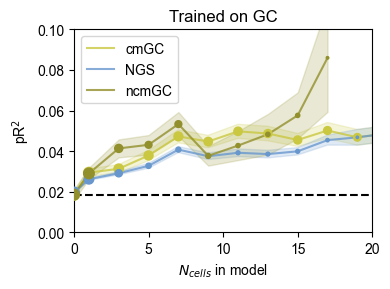

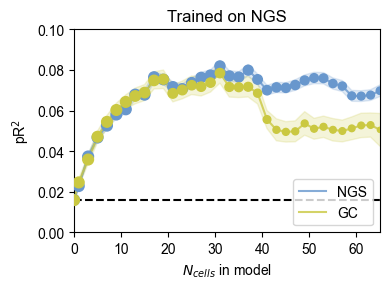

In [164]:
import matplotlib.pyplot as plt

# Define the color palette for tested_on
palette = {'cmGC': '#CAC841', 'ncmGC': "#92902C", 'NGS': '#6897CD', 'GC': '#CAC841'}

# Plot for trained_on == 'GC'
plt.figure(figsize=(4, 3))
for tested_on in data['tested_on'].unique():
    df_plot = data[(data['trained_on'] == 'GC') & (data['tested_on'] == tested_on)]
    if df_plot.empty:
        continue
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.sort_index(axis=1)
    mean = pivot.mean(axis=0)
    sem = pivot.sem(axis=0)
    count = pivot.count(axis=0)
    base_n = count.iloc[0] if len(count) > 0 else 1
    sizes = 60 * (count / base_n)
    color = palette.get(tested_on, None)
    plt.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
    plt.scatter(mean.index, mean.values, s=sizes, color=color, zorder=3)
    plt.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
plt.xlabel('$N_{cells}$ in model')
plt.axhline(mean.values[0], linestyle='--', color='black')
plt.ylabel('pR$^2$')
plt.title('Trained on GC')
plt.legend()
plt.xlim(0, 20)
plt.ylim(0, 0.1)
plt.tight_layout()
plt.show()

# Plot for trained_on == 'NGS'
plt.figure(figsize=(4, 3))
for tested_on in data['tested_on'].unique():
    df_plot = data[(data['trained_on'] == 'NGS') & (data['tested_on'] == tested_on)]
    if df_plot.empty:
        continue
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.sort_index(axis=1)
    mean = pivot.mean(axis=0)
    sem = pivot.sem(axis=0)
    count = pivot.count(axis=0)
    base_n = count.iloc[0] if len(count) > 0 else 1
    sizes = 60 * (count / base_n)
    color = palette.get(tested_on, None)
    plt.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
    plt.scatter(mean.index, mean.values, s=sizes, color=color, zorder=3)
    plt.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
plt.axhline(mean.values[0], linestyle='--', color='black')
plt.xlabel('$N_{cells}$ in model')
plt.ylabel('pR$^2$')
plt.title('Trained on NGS')
plt.legend()
plt.ylim(0, 0.1)
plt.xlim(0, 65)
plt.tight_layout()
plt.show()

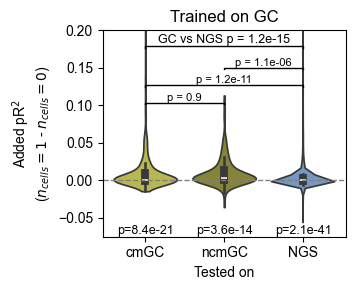

In [157]:
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate added pR2 (difference between n_neurons=1 and n_neurons=0) for each tested_on group
added_pR2 = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = data[(data['trained_on'] == 'GC') & (data['tested_on'] == tested_on) & (data['n_neurons'].isin([0, 1]))]
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    diff = pivot[1] - pivot[0]
    temp_df = pd.DataFrame({'added_pR2': diff, 'tested_on': tested_on})
    added_pR2.append(temp_df)

added_pR2 = pd.concat(added_pR2, ignore_index=True)

# Perform t-tests between each pair of groups and store p-values
groups = ['cmGC', 'ncmGC', 'NGS']
pvals = {}
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = added_pR2[added_pR2['tested_on'] == groups[i]]['added_pR2']
        group2 = added_pR2[added_pR2['tested_on'] == groups[j]]['added_pR2']
        tstat, pval = ttest_ind(group1, group2, nan_policy='omit')
        pvals[(groups[i], groups[j])] = pval

# Additional t-test: (cmGC + ncmGC) vs NGS
group_combined = added_pR2[added_pR2['tested_on'].isin(['cmGC', 'ncmGC'])]['added_pR2']
group_ngs = added_pR2[added_pR2['tested_on'] == 'NGS']['added_pR2']
tstat_comb, pval_comb = ttest_ind(group_combined, group_ngs, nan_policy='omit')

# One-sample t-test for each group vs 0
oneway_pvals = {}
for group in groups:
    vals = added_pR2[added_pR2['tested_on'] == group]['added_pR2']
    tstat, pval = ttest_1samp(vals, 0, nan_policy='omit')
    oneway_pvals[group] = pval

# Set custom colors: green for cmGC/ncmGC, blue for NGS
palette = {'cmGC': '#CAC841', 'ncmGC': "#92902C", 'NGS': '#6897CD'}

plt.figure(figsize=(3.5, 3))
ax = sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2,
    inner='box',
    cut=0,
    palette=palette
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Added pR$^2$\n($n_{cells}=1$ - $n_{cells}=0$)')
plt.xlabel('Tested on')
plt.title('Trained on GC')
plt.tight_layout()
plt.ylim(-0.075, 0.2)

# Annotate p-values above violins (between-group)
y_max = 0.1
y_min = added_pR2['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range

for idx, ((g1, g2), pval) in enumerate(pvals.items()):
    x1, x2 = groups.index(g1), groups.index(g2)
    y = y_start + idx * step
    plt.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    plt.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)

# Annotate combined (cmGC + ncmGC) vs NGS p-value above all
y_comb = y_start + len(pvals) * step + 0.005
plt.plot([0, 0, 2, 2], [y_comb, y_comb+0.002, y_comb+0.002, y_comb], lw=1, c='k')
plt.text(1, y_comb + 0.002, f"GC vs NGS p = {pval_comb:.2g}", ha='center', va='bottom', fontsize=9)

# Annotate one-way t-test p-values below each violin
y_bottom = plt.ylim()[0] + 0.015
for i, group in enumerate(groups):
    plt.text(i, y_bottom, f"p={oneway_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

plt.show()

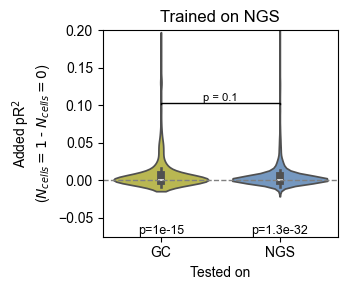

In [158]:
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate added pR2 (difference between n_neurons=1 and n_neurons=0) for each tested_on group
added_pR2 = []
for tested_on in ['GC', 'NGS']:
    df_plot = data[(data['trained_on'] == 'NGS') & (data['tested_on'] == tested_on) & (data['n_neurons'].isin([0, 1]))]
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    diff = pivot[1] - pivot[0]
    temp_df = pd.DataFrame({'added_pR2': diff, 'tested_on': tested_on})
    added_pR2.append(temp_df)

added_pR2 = pd.concat(added_pR2, ignore_index=True)

# Perform t-tests between each pair of groups and store p-values
groups = ['GC','NGS']
pvals = {}
for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        group1 = added_pR2[added_pR2['tested_on'] == groups[i]]['added_pR2']
        group2 = added_pR2[added_pR2['tested_on'] == groups[j]]['added_pR2']
        tstat, pval = ttest_ind(group1, group2, nan_policy='omit')
        pvals[(groups[i], groups[j])] = pval

# One-sample t-test for each group vs 0
oneway_pvals = {}
for group in groups:
    vals = added_pR2[added_pR2['tested_on'] == group]['added_pR2']
    tstat, pval = ttest_1samp(vals, 0, nan_policy='omit')
    oneway_pvals[group] = pval

palette = {'GC': '#CAC841', 'NGS': '#6897CD'}

plt.figure(figsize=(3.5, 3))
ax = sns.violinplot(x='tested_on', y='added_pR2', data=added_pR2, inner='box', cut=0, palette=palette)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Added pR$^2$\n($N_{cells}=1$ - $N_{cells}=0$)')
plt.xlabel('Tested on')
plt.title('Trained on NGS')
plt.tight_layout()
plt.ylim(-0.075, 0.2)

# Annotate p-values above violins (between-group)
y_max = 0.1
y_min = added_pR2['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range

for idx, ((g1, g2), pval) in enumerate(pvals.items()):
    x1, x2 = groups.index(g1), groups.index(g2)
    y = y_start + idx * step
    plt.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    plt.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)

# Annotate one-way t-test p-values below each violin
y_bottom = plt.ylim()[0] + 0.015
for i, group in enumerate(groups):
    plt.text(i, y_bottom, f"p={oneway_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

plt.show()